In [1]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
library(RColorBrewer)
library(data.table)
library(ggplot2)
library(ggsci)

In [2]:
devtools::load_all("utils/modules/R/phasingtools/")

i Loading phasingtools

Loading required package: Hmisc

Loading required package: lattice

Loading required package: survival

Loading required package: Formula


Attaching package: 'Hmisc'


The following objects are masked from 'package:base':

    format.pval, units


Loading required package: stringr

! Skipping missing files: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/R/aggr_ser_by_site.R

! Adding files missing in collate: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/R/aggr_ser_by_pos.R, /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/R/bp_betwen_single_switches.R, /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/R/eval_gt_agreement_by_bin.R, /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasi

In [3]:
sites <- "/well/lindgren/UKBIOBANK/dpalmer/wes_200k/ukb_wes_qc/data/variants/08_final_qc.keep.variant_list"
variants <- fread(sites)

In [14]:

for (i in 1:22){
    
    x <- "AC" %in% colnames(fread(paste0("data/phased/wes_union_calls/200k/shapeit5/parents/ukb_wes_union_calls_200k_shapeit5_parents_chr",i,".txt"), nrows = 2))
    print(x)
}


[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE
[1] TRUE


In [9]:
head(d)

ID,CHR,POS,REF,ALT,MAF,AF,AC,AN,HWE,trio_id,index,switch,switches
<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
.,chr1,794252,C,T,0.0381993,0.961801,383972,399222,0,7,1,0,0
.,chr1,794252,C,T,0.0381993,0.961801,383972,399222,0,26,1,0,0


In [5]:
# setup color scale
col_genome <- "#7BA98A"
col_exome <- "#65B8EF" #"#81A8C9"
my_colors <- c(col_genome, col_exome)
names(my_colors) <- c("Genotyping Array", "Whole Exome Sequencing")
fill_scale <- scale_fill_manual(name = "Variants", values = my_colors)
color_scale <- scale_color_manual(name = "Variants", values = my_colors)

In [6]:
# setup orders
all_chunks <- paste0("", sort(1:20))
autosomes <- paste0("chr",1:22)

In [7]:
path <- "data/phased/wes_union_calls/200k/shapeit5/switch/221117_switch_error_rates_ser_by_chrom.txt.gz"
d_new <- fread(path)
d_new <- d_new[d_new$wes_variant]
d_new <- d_new[,c("CHR","switches","tested")]
colnames(d_new)[2:3] <- paste0("S5_",colnames(d_new)[2:3])

path <- "data/phased/validation/221014_switch_error_rates_ser_by_chrom.txt.gz"
d_old <- fread(path)
d_old <- d_old[d_old$wes_variant]
d_old <- d_old[,c("CHR","switches","tested")]
colnames(d_old)[2:3] <- paste0("S4_",colnames(d_old)[2:3])

In [8]:
merge(d_old, d_new, all = TRUE)

CHR,S4_switches,S4_tested,S5_switches,S5_tested
<chr>,<int>,<int>,<int>,<int>
chr10,145,82797,145,65319
chr11,251,135305,NA,NA
chr12,225,95703,199,75105
chr13,59,33310,40,26347
chr14,128,64312,114,49329
chr15,132,63950,114,48369
chr16,197,96183,175,75942
chr17,230,124438,204,96438
chr18,66,33299,65,25140


In [9]:
d <- fread("data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr22.txt")
nrow(d)
length(unique(d$trio_id))

ERROR: Error in fread("data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr22.txt"): File 'data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr22.txt' does not exist or is non-readable. getwd()=='/gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb'


In [ ]:
d <- fread("data/phased/wes_union_calls/with_parents_test_unphased/ukb_eur_wes_union_calls_200k_chr21.txt")
nrow(d)
length(unique(d$trio_id)) # why did we lose 3 children?

In [43]:
ligated_dir <- "data/phased/wes_scaffold_calls/200k_from_500k/test/
files <- c("data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr21.txt")
#sites <- "/well/lindgren/UKBIOBANK/dpalmer/wes_200k/ukb_wes_qc/data/variants/08_final_qc.keep.variant_list"

In [44]:
files <- list.files(ligated_dir, pattern = ".txt", full.names = TRUE)
files

[1] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr10.txt"
 [2] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr11.txt"
 [3] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr12.txt"
 [4] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr13.txt"
 [5] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr14.txt"
 [6] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr15.txt"
 [7] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr16.txt"
 [8] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr17.txt"
 [9] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr18.txt"
[10] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr19.txt"
[11] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr2.txt" 
[12] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr20.txt"
[13] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr21.txt"
[14] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr22.txt"
[15] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr3.txt" 
[16] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr4.txt" 
[17] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr5.txt" 
[18] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr6.txt" 
[19] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr7.txt" 
[20] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr8.txt" 
[21] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr9.txt"

# Read backed Phasing

In [438]:
final <- fread('data/prephased/wes_union_calls/221124_whatshap_s5_agreement_n10000.txt')

In [441]:
final$pp <- factor(final$pp)
final$bin <- factor(final$bin, levels = labels)

In [442]:
final$bin <- factor(final$bin, levels = labels)

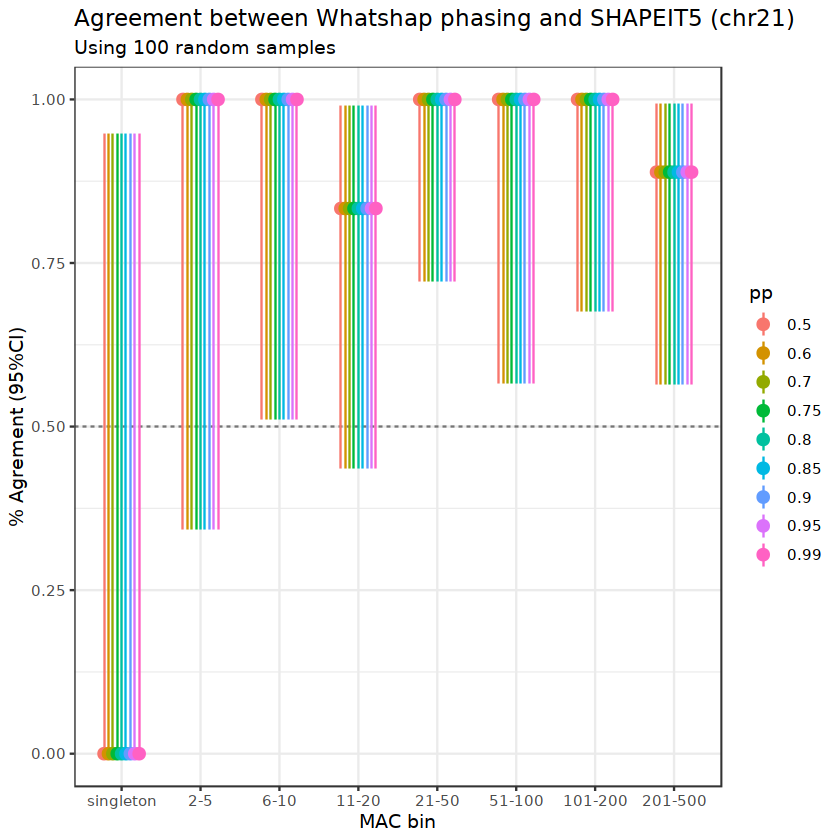

In [443]:
ggplot(final, aes(x=bin,y=pointest, ymin=lower, ymax=upper, color = pp )) +
    geom_hline(yintercept = 0.5, linetype = 'dashed', alpha = 0.5) +
    geom_pointrange(position = position_dodge(width = 0.5)) +
    xlab("MAC bin") +
    ylab("% Agrement (95%CI)") +
    theme_bw() +
    ggtitle("Agreement between Whatshap phasing and SHAPEIT5 (chr21)","Using 100 random samples")


# Chunks by chromosome 

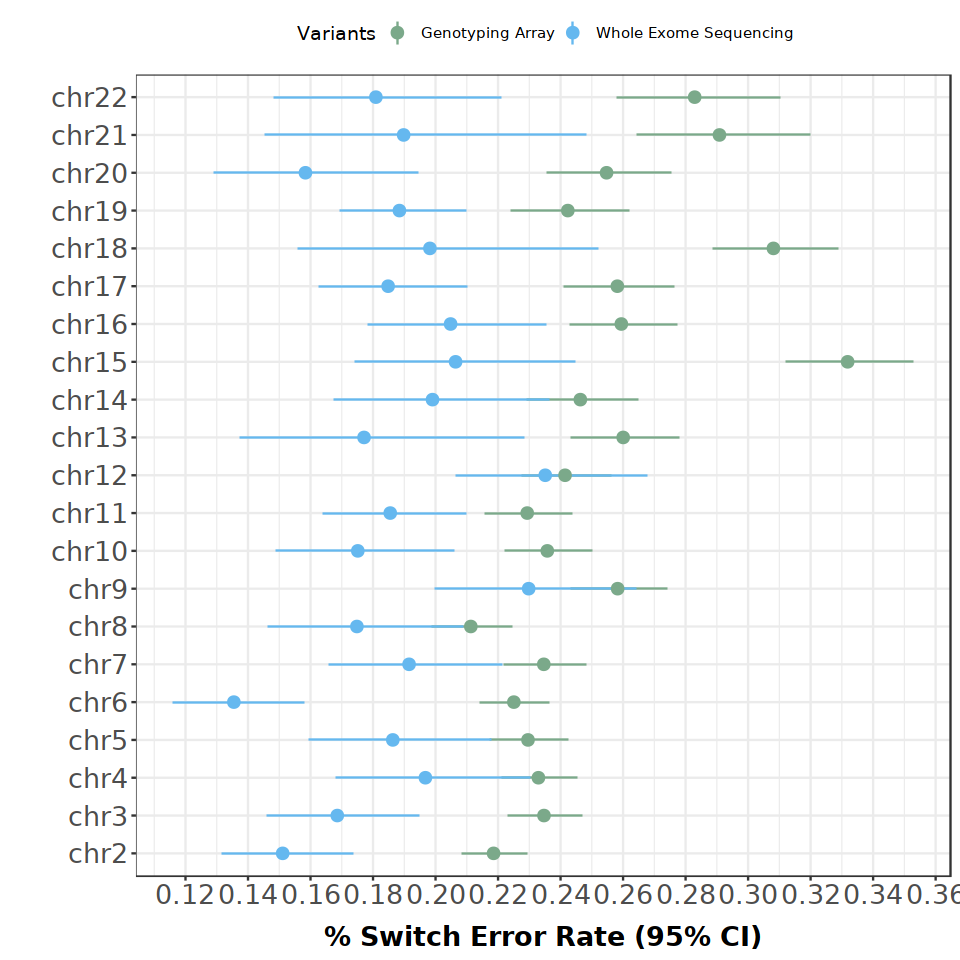

In [6]:
options(repr.plot.width=8, repr.plot.height=8)
path <- "data/phased/wes_union_calls/200k/shapeit5/switch/
d <- fread(path)
d$wes_label <- factor(d$wes_label)
d$chr <- factor(d$CHR, levels = autosomes)
pd <- position_dodge(0.7)
p1 <- ggplot(d,
   aes(
       y=chr,
       x=100*pointest,
       xmax = 100*upper,
       xmin = 100*lower,
       color = factor(wes_label)
   )) +
    theme_bw() +
    geom_pointrange(size = 0.5) +
    labs(color = "") +
    xlab('% Switch Error Rate (95% CI)') + ylab('') +
    color_scale +
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    theme(
        legend.position = "top",
        axis.text=element_text(size=16),
        axis.title=element_text(size=16,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5)
    )

p1

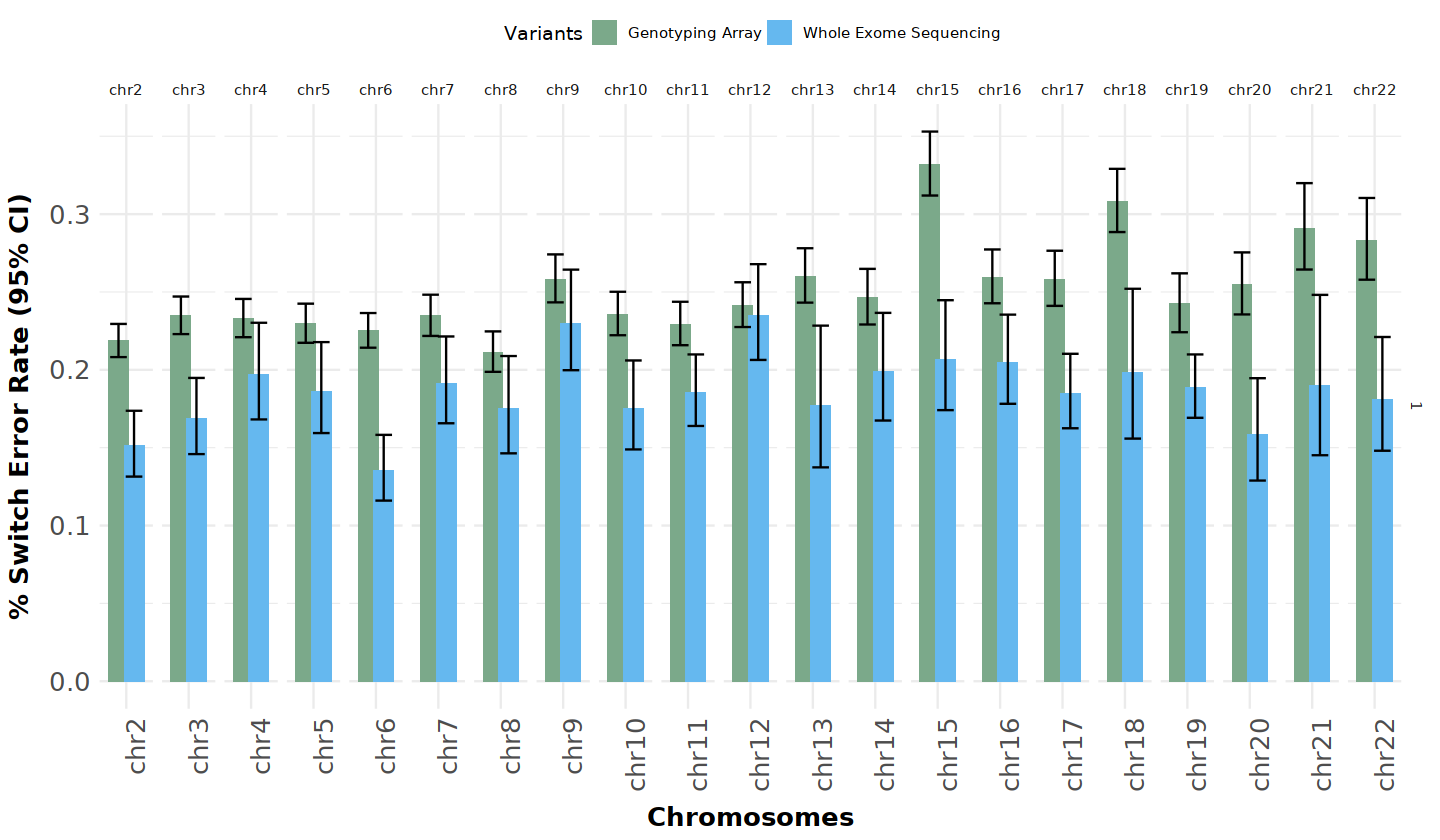

In [7]:
options(repr.plot.width=12, repr.plot.height=7)
p1 <- ggplot(d,
   aes(
       x=chr,
       y=100*pointest,
       ymax = 100*upper,
       ymin = 100*lower,
       fill = wes_label,
   )) +
    theme_minimal() +
    geom_bar(stat = 'identity', position = pd, size = 1) +
    geom_errorbar(stat='identity', position = pd, width = 0.75) +
    ylab('% Switch Error Rate (95% CI)') + 
    xlab('Chromosomes') +
    fill_scale +
    labs(fill = "Hello") +
    scale_y_continuous(breaks=scales::pretty_breaks(n=4)) +
    #scale_x_continuous(breaks=scales::pretty_breaks(n=7)) +
    theme(
        legend.position = "top",
        axis.text=element_text(size=15),
        axis.title=element_text(size=15,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 90, vjust = 1, hjust=0)
    ) +
    facet_grid(1~chr, scales = "free_x") 
    p1

ggsave("derived/plots/220908_switch_errors_by_chromosome.pdf", width = 10, height = 6)

In [10]:
total_switches <- sum(d[d$wes_variant]$switches)
total_tested <- sum(d[d$wes_variant]$tested)
total_errors <- cbind(
    data.frame(switches = total_switches, tested = total_tested),
    Hmisc::binconf(total_switches, total_tested)
)
total_errors

switches,tested,PointEst,Lower,Upper
<int>,<int>,<dbl>,<dbl>,<dbl>
548,2044234,0.0002680711,0.0002465492,0.0002914711


In [11]:
total_switches <- sum(d[!d$wes_variant]$switches)
total_tested <- sum(d[!d$wes_variant]$tested)
total_errors <- cbind(
    data.frame(switches = total_switches, tested = total_tested),
    Hmisc::binconf(total_switches, total_tested)
)
total_errors

switches,tested,PointEst,Lower,Upper
<int>,<int>,<dbl>,<dbl>,<dbl>
7053,9495805,0.000742749,0.0007256221,0.0007602799


# SER by MAF Bins

In [12]:
#d$maf_bin_new <- d$maf_bin
#for (i in 1:nrow(ds)) d$maf_bin_new <- gsub(ds$from1[i], ds$expr[i], d$maf_bin_new)
#for (i in 1:nrow(ds)) d$maf_bin_new <- gsub(ds$from2[i], ds$expr[i], d$maf_bin_new)



from <- c('(1e-06,1e-05]', '(1e-06,1e-05]', '(1e-05,0.0001]', 
          '(1e-05,0.0001]', '(0.0001,0.001]','(0.0001,0.001]',
          '(0.001,0.01]','(0.001,0.01]','(0.01,0.1]',
          '(0.01,0.1]','(0.1,1]','(0.1,1]')

to <- c('[10^-6 10^-5]', '10^-6 - 10^-5', '10[-5] - 10[-4]', 
        '10[-5] - 10[-4]', '10[-4] - 10[-3]','10[-4] - 10[-3]', 
        '10[-3] - 10[-2]', '10[-3] - 10[-2]', '10[-3] - 10[-2]',
        '10[-3] - 10[-2]','10[0] - 10[-1]','10[0] - 10[-1]')

ds <- data.frame(from, to)
#d <- merge(d, ds, by.x = "maf_bin", by.y = "from", all.x = TRUE)

In [13]:
#p3 <- ggplot(d,
#       aes(
#           x=factor(maf_bin, levels = rev(maf_bin_levels)),
#           y=100*pointest,
#           ymax = 100*upper,
#           ymin = 100*lower,
#           fill = factor(wes_label)
#       )) +
#    theme_bw() +
#    geom_bar(stat = 'identity', position = pd, size = 1) +
#    geom_errorbar(stat='identity', position = pd, width = 0.75) +
#    labs(color = "") +
#    ylab('% Switch Error Rate (95% CI)') + xlab('Minor Allele Frequency Bin') +
#    fill_scale + 
#    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
#    theme(
#        legend.position = "top",
#        axis.text=element_text(size=14),
#        axis.title=element_text(size=14,face="bold"),
#        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
#        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
#        plot.title = element_text(hjust=0.5),
#        axis.text.x = element_text(angle = 90, vjust = 0)
#    ) +
#    facet_grid(wes_variant~"Comparison", scale = "free")
#
#p3


In [8]:
# load data
options(repr.plot.width=12, repr.plot.height=8)
path <- "data/phased/validation/221014_switch_error_rates_ser_by_maf.txt.gz"

d <- fread(path)
d$wes_label <- factor(d$wes_label)
table(d$maf_bin)

# 
maf_bin_levels <- c('(1e-06,1e-05]', 
          '(1e-05,0.0001]', 
          '(0.0001,0.001]',
          '(0.001,0.01]',
          '(0.01,0.1]',
          '(0.1,1]')
d$maf_bin <- factor(d$maf_bin, levels = rev(maf_bin_levels))


(0.0001,0.001]   (0.001,0.01]     (0.01,0.1]        (0.1,1] (1e-05,0.0001] 
             2              2              2              2              2 
 (1e-06,1e-05] 
             2 

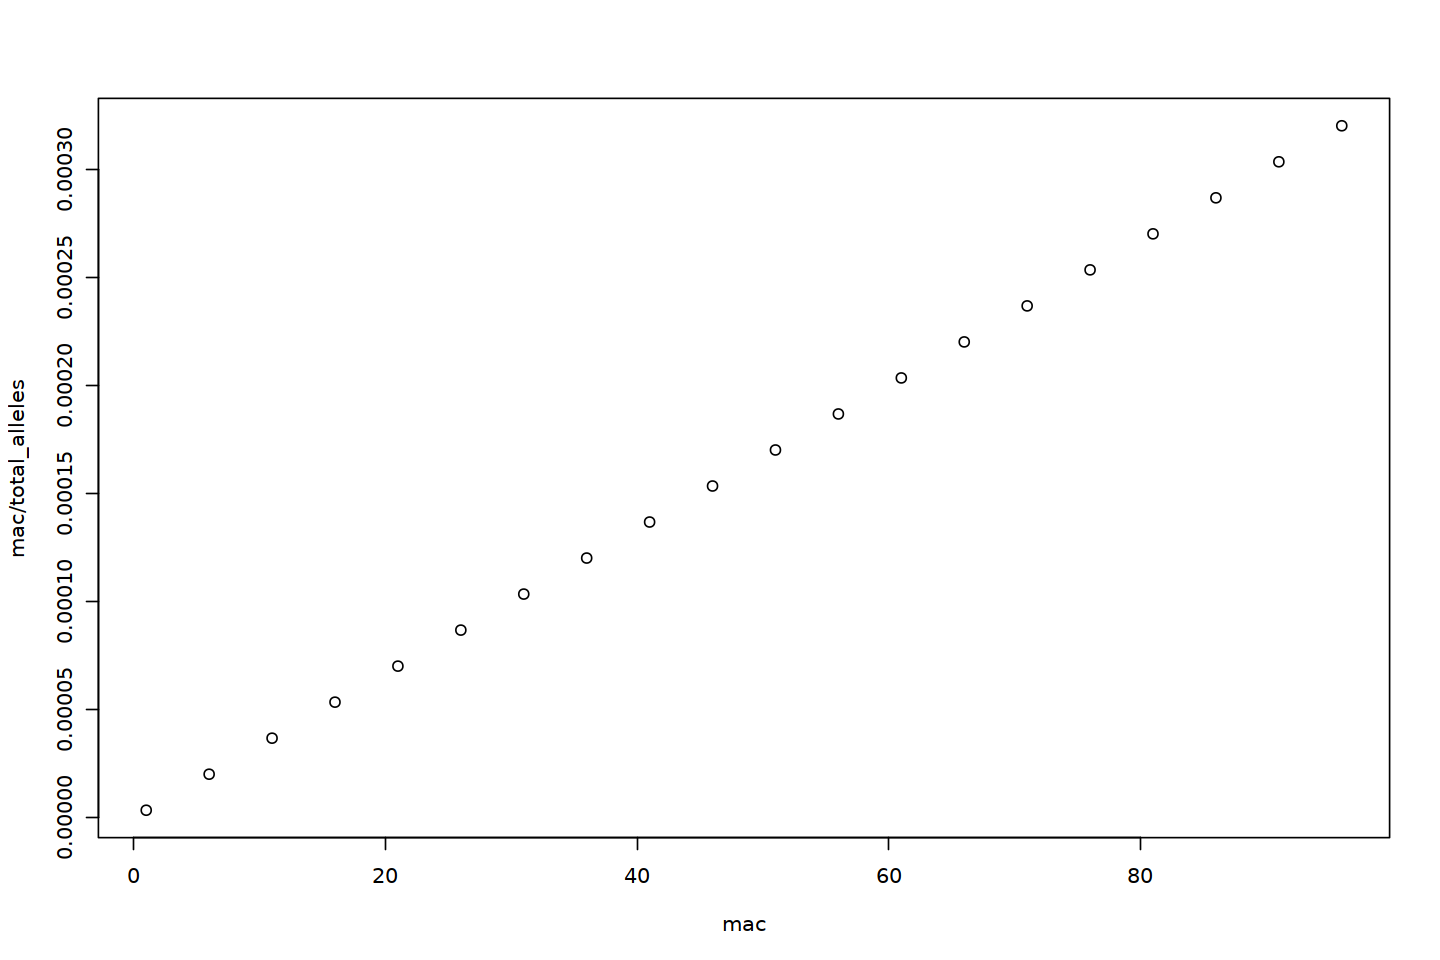

In [20]:
mac = seq(1, 100, by = 5)
total_alleles = 150000 * 2
plot(mac, mac / total_alleles)

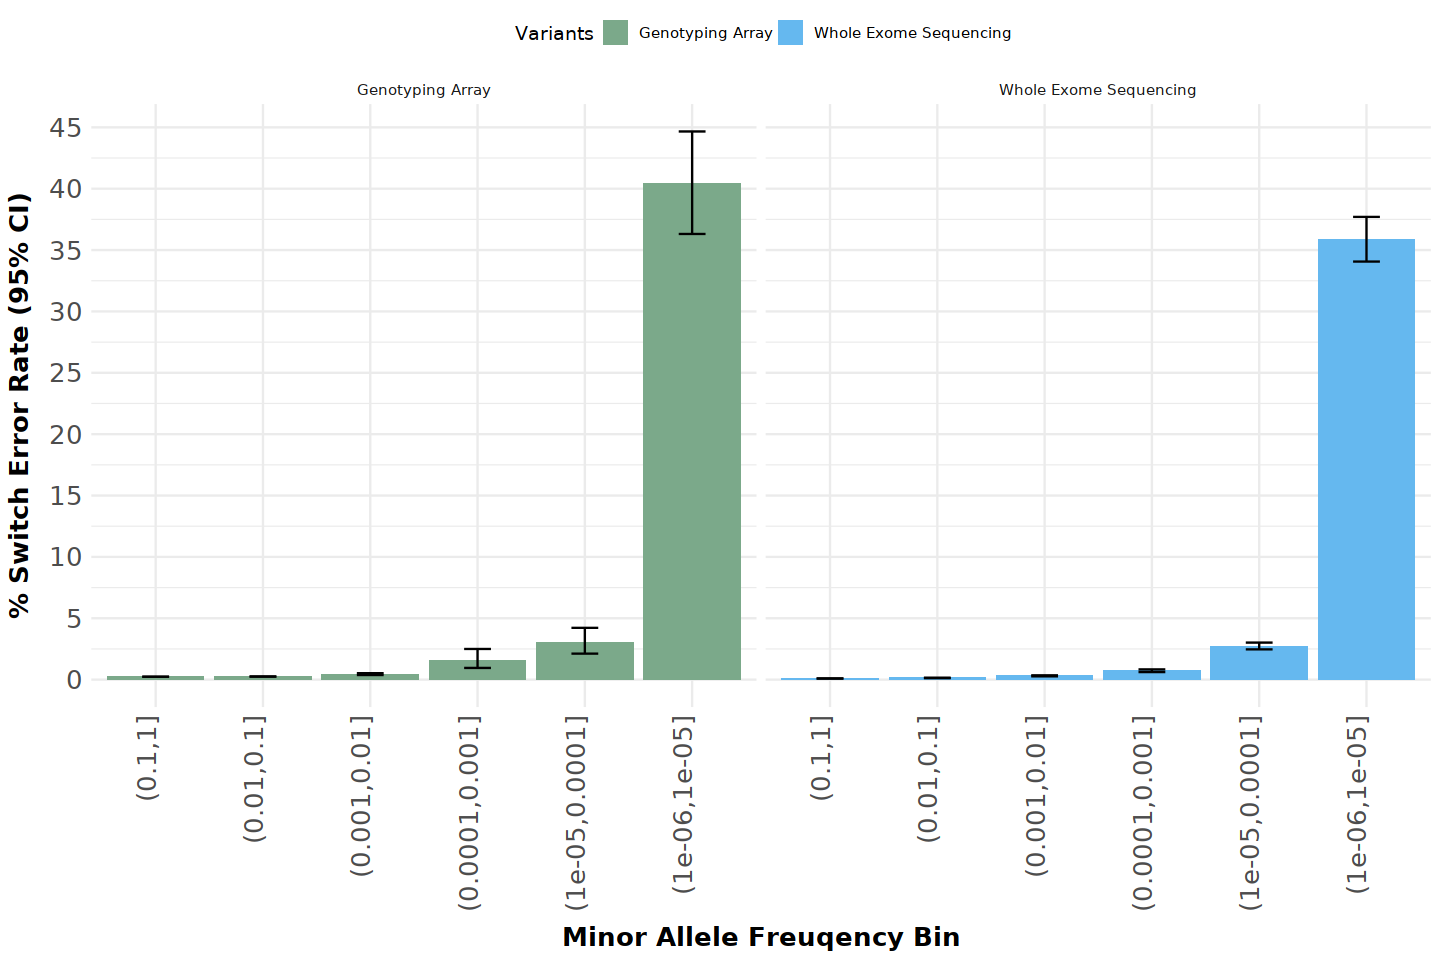

In [14]:
pd <- position_dodge(1)
p1 <- ggplot(d,
   aes(
       x=maf_bin,
       y=100*pointest,
       ymax = 100*upper,
       ymin = 100*lower,
       fill = wes_label,
   )) +
    theme_minimal() +
    geom_bar(stat = 'identity', position = pd, size = 1) +
    geom_errorbar(stat='identity', position = pd, width = 0.25) +
    ylab('% Switch Error Rate (95% CI)') + 
    xlab('Minor Allele Freuqency Bin') +
    fill_scale +
    labs(fill = "Hello") +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    theme(
        legend.position = "top",
        axis.text=element_text(size=15),
        axis.title=element_text(size=15,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 90, vjust = 0, hjust=1)
    ) +
    facet_wrap(~wes_label) 

p1

[1] 1e-06

In [17]:
d$wes_variant

[1] FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE

In [18]:
path <- "data/phased/validation/220713_ukb_eur_wes_union_calls_phasing_eagle_shapeit4.txt.gz"
d <- fread(path)
d$wes_label <- factor(d$wes_label)
d$chunk_current_w_label <- paste0("p",d$chunk_current)
d <- d[d$CHR %in% c("chr21","chr22")]
head(d, n = 2)

wes_variant,chunk_current,CHR,switches,tested,method,pointest,lower,upper,wes_label,chunk_current_w_label
<lgl>,<int>,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
FALSE,1,chr21,256,147042,Eagle2,0.0017409992,0.0015405386,0.001967493,Genotyping Array,p1
TRUE,1,chr21,26,28489,Eagle2,0.0009126329,0.0006229079,0.001336934,Whole Exome Sequencing,p1


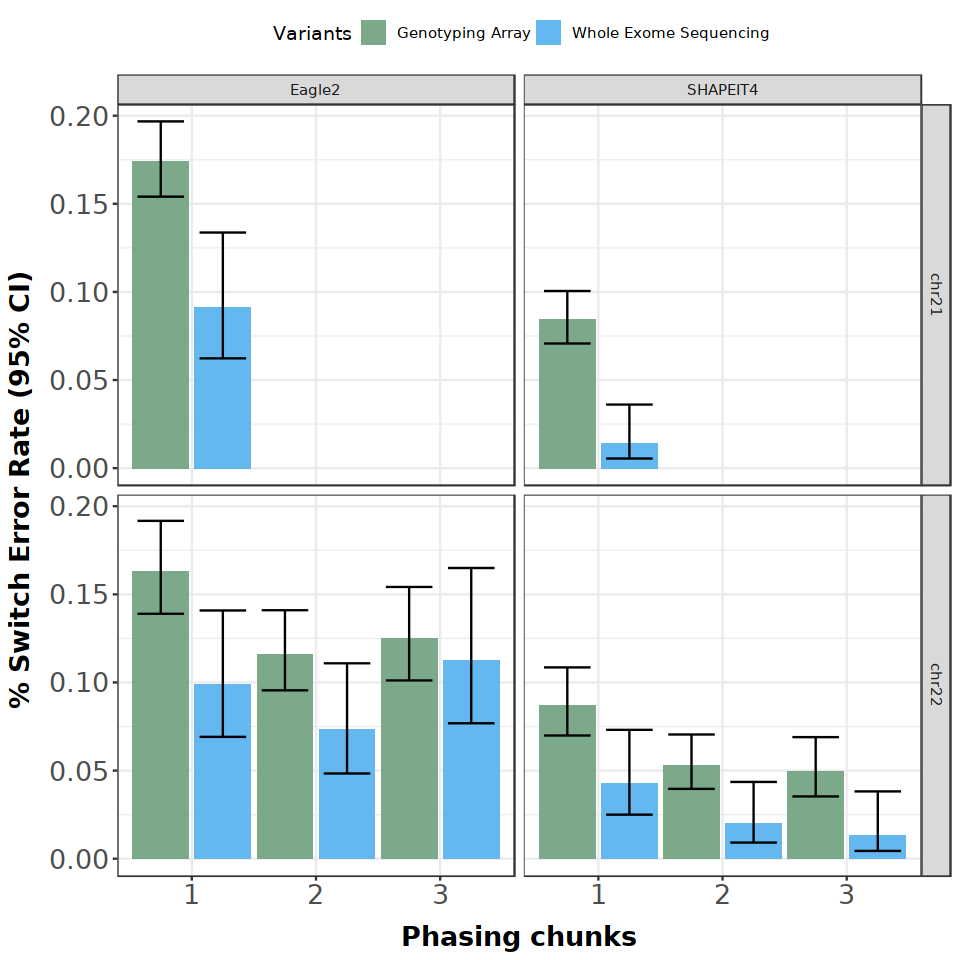

In [19]:
options(repr.plot.width=8, repr.plot.height=8)
pd <- position_dodge(1)
p1 <- ggplot(d,
   aes(
       x=factor(chunk_current),
       y=100*pointest,
       ymax = 100*upper,
       ymin = 100*lower,
       fill = wes_label,
   )) +
    theme_bw() +
    geom_bar(stat = 'identity', position = pd, size = 1) +
    geom_errorbar(stat='identity', position = pd,width = 0.75) +
    ylab('% Switch Error Rate (95% CI)') + 
    xlab('Phasing chunks') +
    fill_scale +
    labs(fill = "Hello") +
    #scale_y_continuous(breaks=scales::pretty_breaks(n=4)) +
    #scale_x_continuous(breaks=scales::pretty_breaks(n=7)) +
    facet_grid(CHR~method) +
    theme(
        legend.position = "top",
        axis.text=element_text(size=16),
        axis.title=element_text(size=16,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5)
       # axis.text.x = element_text(angle = 0, vjust = 1, hjust=0)
    )
    p1

In [20]:
options(repr.matrix.max.rows=270, repr.matrix.max.cols=30)
d

wes_variant,chunk_current,CHR,switches,tested,method,pointest,lower,upper,wes_label,chunk_current_w_label
<lgl>,<int>,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
FALSE,1,chr21,256,147042,Eagle2,0.0017409992,1.540539e-03,0.0019674930,Genotyping Array,p1
TRUE,1,chr21,26,28489,Eagle2,0.0009126329,6.229079e-04,0.0013369338,Whole Exome Sequencing,p1
FALSE,1,chr22,148,90669,Eagle2,0.0016323109,1.389820e-03,0.0019170299,Genotyping Array,p1
TRUE,1,chr22,30,30397,Eagle2,0.0009869395,6.914383e-04,0.0014085516,Whole Exome Sequencing,p1
FALSE,2,chr22,101,87028,Eagle2,0.0011605460,9.552974e-04,0.0014098308,Genotyping Array,p2
TRUE,2,chr22,22,30039,Eagle2,0.0007323812,4.837249e-04,0.0011087163,Whole Exome Sequencing,p2
FALSE,3,chr22,86,68860,Eagle2,0.0012489108,1.011487e-03,0.0015419791,Genotyping Array,p3
TRUE,3,chr22,26,23089,Eagle2,0.0011260774,7.686132e-04,0.0016495153,Whole Exome Sequencing,p3
FALSE,1,chr21,124,147049,SHAPEIT4,0.0008432563,7.073669e-04,0.0010052247,Genotyping Array,p1


# compare old WES naive phasing with WES+GENO union

In [77]:
fread_phased_sites <- function(file, ...){

    # get details about chunks
    bname <- basename(file)
    chunk_current <- as.numeric(gsub("of","",stringr::str_extract(bname, "[0-9]+of")))
    chunk_final <- as.numeric(gsub("of","",stringr::str_extract(bname, "of[0-9]+")))
    method <- unlist(strsplit(bname, split = '_'))[1]
    phasing_region_size <- as.numeric(gsub("_prs","",stringr::str_extract(bname, "_prs[0-9]+")))
    phasing_overlap_size <- as.numeric(gsub("_pro","",stringr::str_extract(bname, "_pro[0-9]+")))
    max_phasing_region_size <- as.numeric(gsub("_mprs","",stringr::str_extract(bname, "_mprs[0-9]+")))

    # append to data.table
    d <- fread(file, ...)
    d$locus <- paste0(d$CHR,":",d$POS)
    d$chunk_current <- chunk_current
    d$chunk_final <- chunk_final
    d$method <- method
    d$phasing_region_size <- phasing_region_size
    d$phasing_overlap_size <- phasing_overlap_size
    d$max_phasing_region_size <- max_phasing_region_size
    return(d)

}

In [78]:
files_chr22 <- list.files("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/phased/wes/chunks/final/ukb_eur_wes_200k_chr22-18xshort.qe", pattern = '.txt', full.names = TRUE)
files_chr22 <- files_chr22[!grepl('shapeit4_prs150000_pro75000_mprs200000.1of1.txt', files_chr22)]

In [79]:
files_chr21 <- list.files("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/phased/wes/chunks/final/ukb_eur_wes_200k_chr21-18xshort.qe/", pattern = '.txt', full.names = TRUE)
files_chr21 <- files_chr21[1]

In [80]:
files <- c(files_chr21, files_chr22)

In [87]:
chroms <- c("chr21","chr22")
lst <- lapply(chroms, function(chr){

    # subset by chromosome (if we read in all at the same time it takes too long)
    files_chr <- files[grepl(paste0(chr,"-"), files)]
    d <- data.table(do.call(rbind, lapply(files_chr, fread_phased_sites)))
    d$wes_variant <- TRUE

    # get counts
    counts <- aggregate(switches ~ wes_variant + chunk_current + CHR, data = d, FUN = sum)
    tested <- aggregate(switches ~ wes_variant + chunk_current + CHR, data = d, FUN = length)
    counts <- data.table(counts, tested = tested$switches)
    return(counts)
})


In [88]:
# combine counts and add conf int
counts <- do.call(rbind, lst)
counts_ci <- do.call(rbind, lapply(1:nrow(counts), function(i) Hmisc::binconf(counts$switches[i], counts$tested[i])))
colnames(counts_ci) <- tolower(colnames(counts_ci))
counts <- cbind(counts, counts_ci)

In [90]:
counts

wes_variant,chunk_current,CHR,switches,tested,pointest,lower,upper
<lgl>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
TRUE,1,chr21,1173,22094,0.053091337,0.05021177,0.056126283
TRUE,1,chr22,696,24130,0.028843763,0.02680586,0.031031659
TRUE,2,chr22,325,25379,0.012805863,0.01149444,0.014264755
TRUE,3,chr22,126,16905,0.007453416,0.00626408,0.008866552
